# NASA IMS Bearing Dataset | Model Generalization
We test whether the Random Forest classifier trained on Test 1 generalizes 
to Test 2 and Test 3. These tests have a different sensor configuration 
(2 channels per bearing instead of 1), different test durations, and 
different failure bearings. This is the real test of the model's usefulness.

Known failure bearings:
Test 1 | Bearing 3 (outer race)
Test 2 | Bearing 1 (outer race)
Test 3 | Bearing 3 (outer race) ; Bearing 4 (roller element)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.pipeline import Pipeline

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR_1 = Path("../data/1st_test")
DATA_DIR_2 = Path("../data/2nd_test")
DATA_DIR_3 = Path("../data/3rd_test")

BEARINGS_4CH = ["bearing_1", "bearing_2", "bearing_3", "bearing_4"]
BEARINGS_8CH = [
    "bearing_1_ch1", "bearing_1_ch2",
    "bearing_2_ch1", "bearing_2_ch2",
    "bearing_3_ch1", "bearing_3_ch2",
    "bearing_4_ch1", "bearing_4_ch2"
]

## Step 1: Feature Extraction Functions
We write two extraction functions, one for the 4 channel format (Test 1) 
and one for the 8 channel format (Tests 2 and 3). For the 8 channel format 
we average the two channels per bearing before extracting features, 
producing the same 6 features per bearing as Test 1.

In [5]:
def extract_features_4ch(data_dir):
    bearings = BEARINGS_4CH
    files = sorted([f for f in data_dir.iterdir() if f.is_file()])
    records = []

    for file in files:
        df = pd.read_csv(file, sep="\t", header=None, names=bearings)
        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )
        record = {"timestamp": timestamp}
        for b in bearings:
            signal = df[b].values
            rms = np.sqrt(np.mean(signal**2))
            record[f"{b}_rms"]       = rms
            record[f"{b}_std"]       = np.std(signal)
            record[f"{b}_kurtosis"]  = pd.Series(signal).kurtosis()
            record[f"{b}_peak"]      = np.max(np.abs(signal))
            record[f"{b}_crest"]     = np.max(np.abs(signal)) / (rms + 1e-10)
            record[f"{b}_peak2peak"] = np.max(signal) - np.min(signal)
        records.append(record)

    return pd.DataFrame(records).set_index("timestamp")


def extract_features_8ch(data_dir):
    files = sorted([f for f in data_dir.iterdir() if f.is_file()])
    records = []

    for file in files:
        df = pd.read_csv(file, sep="\t", header=None, names=BEARINGS_8CH)
        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )
        record = {"timestamp": timestamp}
        for i in range(1, 5):
            b = f"bearing_{i}"
            # Average the two channels for this bearing
            signal = (df[f"{b}_ch1"].values + df[f"{b}_ch2"].values) / 2
            rms = np.sqrt(np.mean(signal**2))
            record[f"{b}_rms"]       = rms
            record[f"{b}_std"]       = np.std(signal)
            record[f"{b}_kurtosis"]  = pd.Series(signal).kurtosis()
            record[f"{b}_peak"]      = np.max(np.abs(signal))
            record[f"{b}_crest"]     = np.max(np.abs(signal)) / (rms + 1e-10)
            record[f"{b}_peak2peak"] = np.max(signal) - np.min(signal)
        records.append(record)

    return pd.DataFrame(records).set_index("timestamp")


print("Extracting Test 1 features...")
features_1 = extract_features_4ch(DATA_DIR_1)
print(f"Test 1 shape: {features_1.shape}")

print("Extracting Test 2 features...")
features_2 = extract_features_8ch(DATA_DIR_2)
print(f"Test 2 shape: {features_2.shape}")

print("Extracting Test 3 features...")
features_3 = extract_features_8ch(DATA_DIR_3)
print(f"Test 3 shape: {features_3.shape}")

Extracting Test 1 features...
Test 1 shape: (2156, 24)
Extracting Test 2 features...
Test 2 shape: (984, 24)
Extracting Test 3 features...
Test 3 shape: (6324, 24)


## Step 2: Retrain Model on Full Test 1
We retrain the Random Forest on all 4 bearings from Test 1 this time, 
not just Bearings 1 and 2. Since we are now testing on completely 
different test runs rather than a held out bearing, we can use all 
available Test 1 data for training.

In [6]:
def make_labels(n, degraded_threshold=0.80):
    labels = np.zeros(n, dtype=int)
    cutoff = int(n * degraded_threshold)
    labels[cutoff:] = 1
    return labels

n1 = len(features_1)
labels_1 = make_labels(n1)

bearing_cols = [c for c in features_1.columns if any(f"bearing_{i}_" in c for i in range(1, 5))]

X_train = features_1[bearing_cols].values
y_train = np.tile(labels_1, 1)

# Stack all 4 bearings from Test 1 as training data
X_all = np.vstack([
    features_1[[c for c in features_1.columns if "bearing_1" in c]].values,
    features_1[[c for c in features_1.columns if "bearing_2" in c]].values,
    features_1[[c for c in features_1.columns if "bearing_3" in c]].values,
    features_1[[c for c in features_1.columns if "bearing_4" in c]].values,
])
y_all = np.tile(labels_1, 4)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])

pipeline.fit(X_all, y_all)
print("Model retrained on all Test 1 bearings")

Model retrained on all Test 1 bearings


## Step 3: Evaluate on Test 2
The known failure bearing in Test 2 is Bearing 1.


Test2 | bearing_1 | AUC: 0.491
              precision    recall  f1-score   support

     Healthy       0.84      1.00      0.91       787
    Degraded       1.00      0.23      0.37       197

    accuracy                           0.85       984
   macro avg       0.92      0.61      0.64       984
weighted avg       0.87      0.85      0.80       984



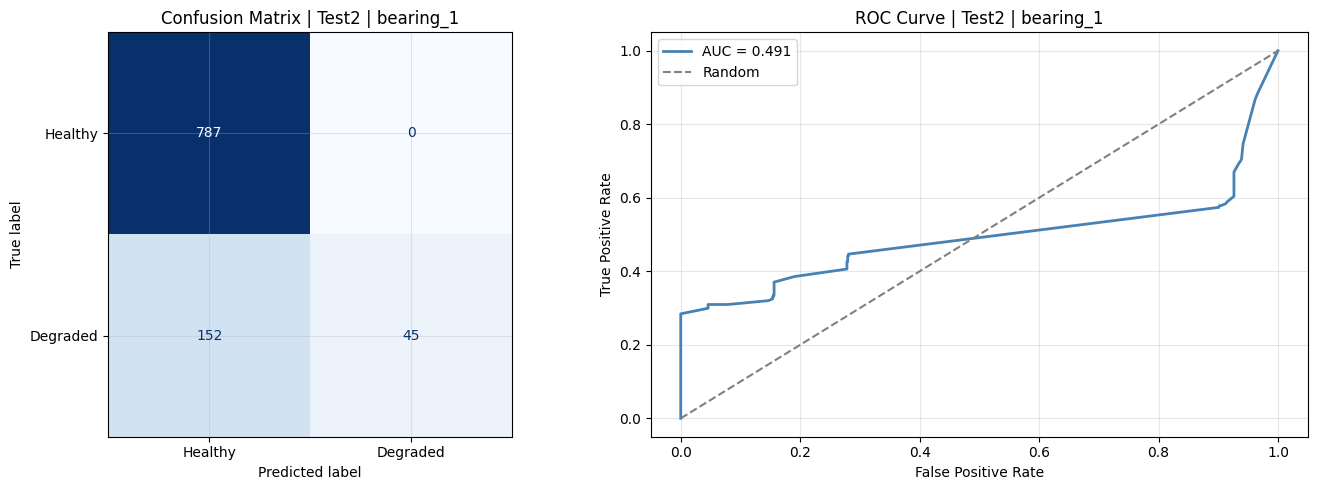

In [7]:
def evaluate_bearing(pipeline, features, bearing, test_name, degraded_threshold=0.80):
    n = len(features)
    labels = make_labels(n, degraded_threshold)
    
    bearing_cols = [c for c in features.columns if bearing in c]
    X = features[bearing_cols].values
    
    y_pred = pipeline.predict(X)
    y_prob = pipeline.predict_proba(X)[:, 1]
    
    fpr, tpr, _ = roc_curve(labels, y_prob)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n{test_name} | {bearing} | AUC: {roc_auc:.3f}")
    print(classification_report(labels, y_pred, target_names=["Healthy", "Degraded"]))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix
    cm = confusion_matrix(labels, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Degraded"])
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"Confusion Matrix | {test_name} | {bearing}")
    
    # ROC curve
    axes[1].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve | {test_name} | {bearing}")
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/06_{test_name}_{bearing}.png", dpi=150)
    plt.show()
    
    return roc_auc

# Test 2 — failure bearing is Bearing 1
auc_t2_b1 = evaluate_bearing(pipeline, features_2, "bearing_1", "Test2")

## Step 4: Evaluate on Test 3
Test 3 has two failure bearings; Bearing 3 (outer race) and Bearing 4 (roller element).
We evaluate both and compare whether the model catches different failure modes equally well.


Test3 | bearing_3 | AUC: 0.500
              precision    recall  f1-score   support

     Healthy       0.80      1.00      0.89      5059
    Degraded       0.00      0.00      0.00      1265

    accuracy                           0.80      6324
   macro avg       0.40      0.50      0.44      6324
weighted avg       0.64      0.80      0.71      6324



c:\Users\germa\OneDrive\Escritorio\python projects\nasa-bearing-eda\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\germa\OneDrive\Escritorio\python projects\nasa-bearing-eda\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\germa\OneDrive\Escritorio\python projects\nasa-bearing-eda\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

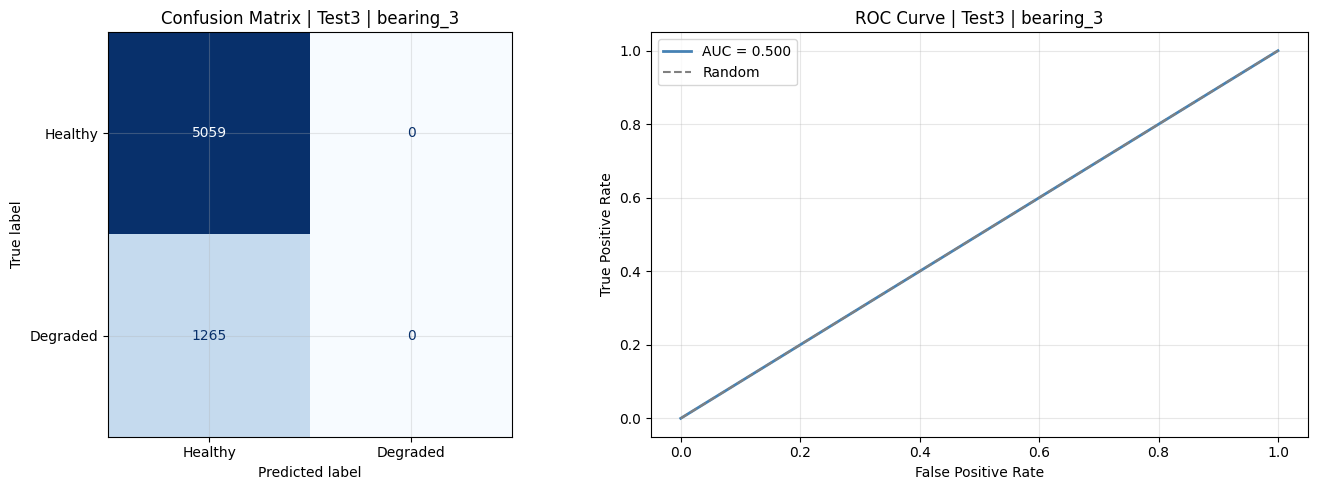


Test3 | bearing_4 | AUC: 0.500
              precision    recall  f1-score   support

     Healthy       0.80      1.00      0.89      5059
    Degraded       0.00      0.00      0.00      1265

    accuracy                           0.80      6324
   macro avg       0.40      0.50      0.44      6324
weighted avg       0.64      0.80      0.71      6324



c:\Users\germa\OneDrive\Escritorio\python projects\nasa-bearing-eda\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\germa\OneDrive\Escritorio\python projects\nasa-bearing-eda\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\germa\OneDrive\Escritorio\python projects\nasa-bearing-eda\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

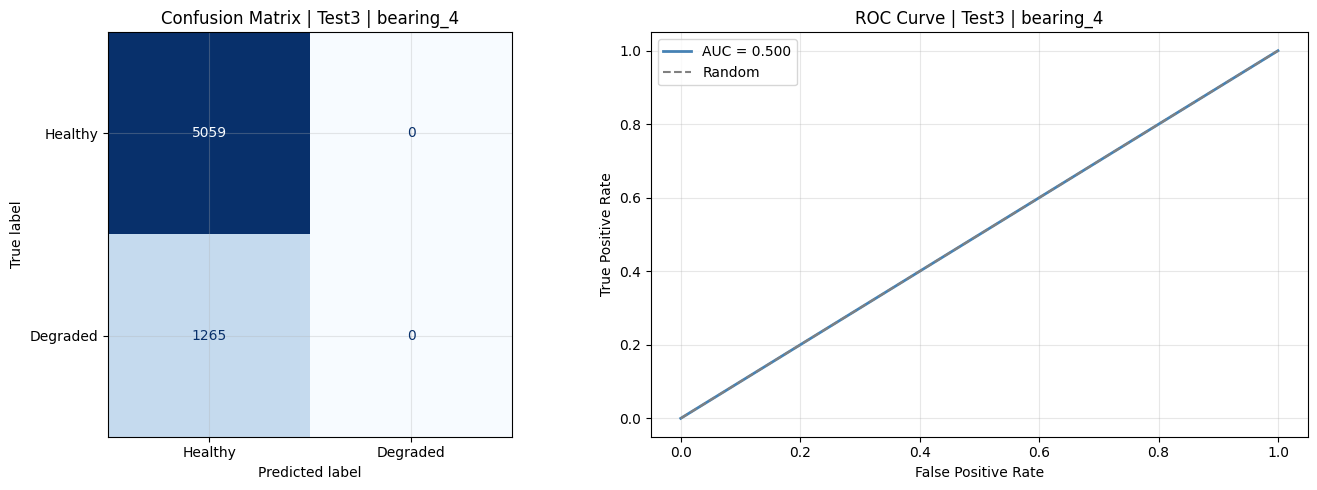

In [8]:
auc_t3_b3 = evaluate_bearing(pipeline, features_3, "bearing_3", "Test3")
auc_t3_b4 = evaluate_bearing(pipeline, features_3, "bearing_4", "Test3")

## Step 5: Generalization Summary
Comparing AUC scores across all evaluations gives us a clear picture 
of how consistently the model performs across different test runs and failure modes.

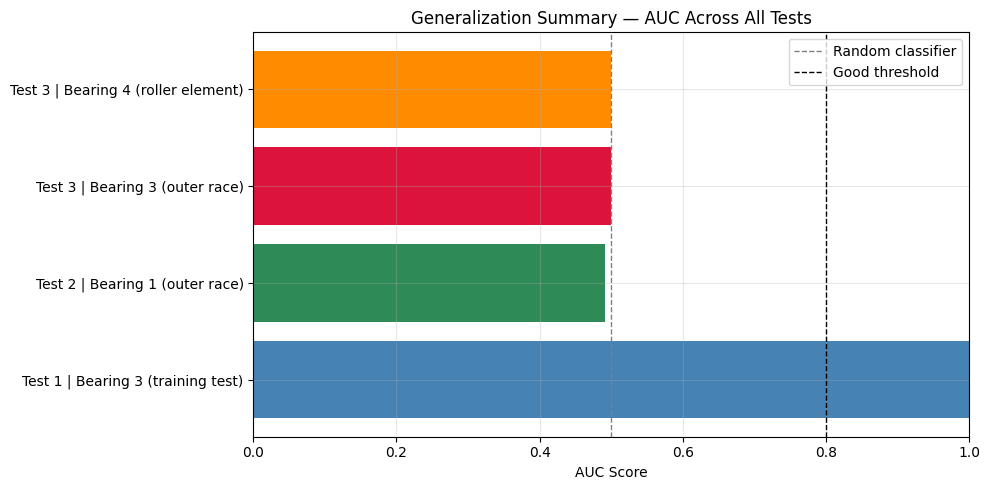

In [9]:
results = {
    "Test 1 | Bearing 3 (training test)": 0,
    "Test 2 | Bearing 1 (outer race)": auc_t2_b1,
    "Test 3 | Bearing 3 (outer race)": auc_t3_b3,
    "Test 3 | Bearing 4 (roller element)": auc_t3_b4,
}

# Get Test 1 Bearing 3 AUC for reference
n1 = len(features_1)
labels_1_ref = make_labels(n1)
X_t1_b3 = features_1[[c for c in features_1.columns if "bearing_3" in c]].values
y_prob_t1_b3 = pipeline.predict_proba(X_t1_b3)[:, 1]
fpr, tpr, _ = roc_curve(labels_1_ref, y_prob_t1_b3)
results["Test 1 | Bearing 3 (training test)"] = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue", "seagreen", "crimson", "darkorange"]
bars = ax.barh(list(results.keys()), list(results.values()), color=colors)
ax.set_xlim(0, 1)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Random classifier")
ax.axvline(0.8, color="black", linestyle="--", linewidth=1, label="Good threshold")
ax.set_xlabel("AUC Score")
ax.set_title("Generalization Summary — AUC Across All Tests")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/06_generalization_summary.png", dpi=150)
plt.show()

## Key Findings
The model performed well on Test 1 but failed to generalize to Tests 2 and 3,
scoring AUC values of 0.491, 0.500 and 0.500 respectively, which is equivalent
to random guessing. The confusion matrices confirm this; the model predicted
everything as Healthy on the unseen tests and never triggered a Degraded prediction.

This reveals a fundamental limitation of the fixed 80|20 time threshold labeling approach.
The model learned feature values specific to Test 1's degradation timeline, and since
Tests 2 and 3 have different durations and failure patterns, those learned thresholds
simply do not transfer. This is a common and important problem in real predictive
maintenance systems; a model trained on one machine does not automatically work on another.

The natural next step is replacing the fixed time threshold with a data-driven approach,
flagging degradation when features deviate significantly from each test's own baseline
rather than relying on a universal time cutoff.